# TD 1 — Nettoyage et Préparation des Données DVF
## Prédiction des Prix Immobiliers en Île-de-France

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afaflwafi/enpc_td/blob/master/TD/TD1.ipynb)

**Cours : Data Science Appliquée — École des Ponts ParisTech**

Ce TD est le **point de départ** du projet fil rouge : prédire les prix immobiliers en Île-de-France. Nous utilisons les données DVF (*Demandes de Valeurs Foncières*), publiées par la DGFiP sur [data.gouv.fr](https://www.data.gouv.fr/datasets/demandes-de-valeurs-foncieres).

---

## Objectifs du TD

1. **Comprendre la structure inhabituelle des données DVF** — pourquoi 1 ligne ≠ 1 transaction
2. **Nettoyer et typer correctement les colonnes** — formats français, valeurs manquantes
3. **Agréger les lignes** pour obtenir 1 transaction = 1 ligne
4. **Détecter et éliminer les valeurs aberrantes** — par connaissance métier et statistiques
5. **Construire la variable cible** : le prix au m²
6. **Créer des features pertinentes** — temporelles, géographiques
7. **Explorer visuellement le dataset** et en comprendre les grandes tendances

## Table des matières

1. [Installation & Imports](#1)
2. [Chargement des données](#2)
3. [Exploration initiale](#3)
4. [**Le problème central DVF** : 1 ligne ≠ 1 transaction](#4)
5. [Nettoyage de base & conversions de types](#5)
6. [Filtrage métier](#6)
7. [Agrégation par transaction](#7)
8. [Calcul du prix/m² & détection des outliers](#8)
9. [Ingénierie des features](#9)
10. [Export du dataset propre](#10)

---
## 1. Installation & Imports <a id='1'></a>

In [ ]:
# En Colab, la plupart des librairies sont déjà disponibles
# On installe uniquement ce qui manque
!pip install -q seaborn --upgrade

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Style global pour les graphiques
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('tab10')

# Formatters utiles
fmt_euro = mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €')
fmt_keur = mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€')
fmt_meur = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€')

print('✓ Librairies chargées')
print(f'  pandas  {pd.__version__}')
print(f'  numpy   {np.__version__}')
print(f'  seaborn {sns.__version__}')

✓ Librairies chargées
  pandas  2.2.3
  numpy   2.1.3
  seaborn 0.13.2


---
## 2. Chargement des données <a id='2'></a>

Avant ce notebook, vous devez avoir suivi le tutoriel (fichier instructions à la racine du projet). Vous devriez alors avoir les données dans un dossier `DATA_ENPC_PROJECT`à la racine de votre Drive.

Merci également de prendre connaissance de la documentation du jeu de données, dans le dossier `DOCUMENTATION`.

In [ ]:
!git clone https://github.com/afaflwafi/enpc_td.git
!git lfs fetch --all


In [ ]:
# ─── Configuration ────────────────────────────────────────────────────────────
# Adaptez DATA_PATH selon l'emplacement de votre fichier
DATA_PATH = '/enpc_td/DATA/dvf_idf.csv'
IN_COLAB = True

print(f'  Chemin des données : {DATA_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Chemin des données : /content/drive/MyDrive/DATA_ENPC_PROJECT/dvf_idf.csv


In [ ]:
# Chargement en mode string brut : on laisse pandas décider des types APRÈS nettoyage
# C'est une bonne pratique pour les données avec des formats non-standard (virgule décimale, etc.)

df_raw = pd.read_csv(DATA_PATH, dtype=str, low_memory=False)

print(f'Dataset chargé !')
print(f'  Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print(f'  Mémoire    : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nColonnes :')
for i, col in enumerate(df_raw.columns):
    print(f'  {i:2d}. {col}')

Dataset chargé !
  Dimensions : 1,984,815 lignes × 32 colonnes
  Mémoire    : 3026.6 MB

Colonnes :
   0. id_mutation
   1. date_mutation
   2. nature_mutation
   3. valeur_fonciere
   4. numero_disposition
   5. adresse_numero
   6. adresse_nom_voie
   7. code_postal
   8. nom_commune
   9. code_departement
  10. code_commune
  11. id_parcelle
  12. lot1_numero
  13. lot1_surface_carrez
  14. lot2_numero
  15. lot2_surface_carrez
  16. lot3_numero
  17. lot3_surface_carrez
  18. lot4_numero
  19. lot4_surface_carrez
  20. lot5_numero
  21. lot5_surface_carrez
  22. nombre_lots
  23. code_type_local
  24. type_local
  25. surface_reelle_bati
  26. nombre_pieces_principales
  27. code_nature_culture
  28. surface_terrain
  29. longitude
  30. latitude
  31. annee


---
## 3. Exploration initiale — on commence par Paris <a id='3'></a>

Avant de travailler sur toute l'Île-de-France, on **zoom sur Paris (75)** :
c'est un sous-ensemble géographiquement cohérent, plus compact, et dont on connait intuitivement les prix.
C'est une bonne pratique en data science : comprendre la structure sur un sous-ensemble avant de scaler.

> **Objectif de cette section :** découvrir progressivement pourquoi DVF est un dataset tricky,
> en partant de l'observation brute, sans rien savoir à l'avance.

In [ ]:
#-------------------------------------------------------------------------------------------------------
################################################# TO DO ################################################
# On souhaite faire une copie de notre dataframe mais en isolant Paris
# On récupère uniquement les lignes qui correspondent à la ville de Paris (indice -> regarder le département)
paris = ....
#-------------------------------------------------------------------------------------------------------

print(f'Paris : {len(paris):,} lignes, {paris.shape[1]} colonnes')
print(f'Rues distinctes  : {paris["adresse_nom_voie"].nunique():,}')
print(f'Codes commune    : {sorted(paris["code_commune"].unique())}')
print()

# Colonnes les plus utiles pour commencer
KEY_COLS = [
    'date_mutation', 'valeur_fonciere', 'nature_mutation',
    'adresse_numero', 'adresse_nom_voie', 'code_postal',
    'type_local', 'surface_reelle_bati', 'nombre_pieces_principales',
    'nombre_lots', 'numero_disposition'
]
paris[KEY_COLS].head(12)


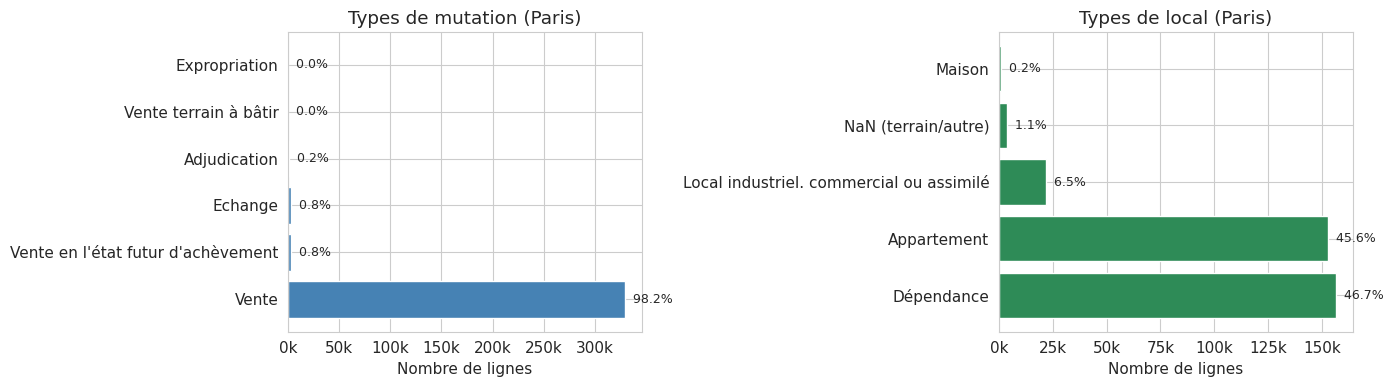

In [ ]:
# Que contient le dataset à Paris ?

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Nature des mutations
nat = paris['nature_mutation'].value_counts()
axes[0].barh(nat.index, nat.values, color='steelblue')
axes[0].set_title('Types de mutation (Paris)')
axes[0].set_xlabel('Nombre de lignes')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for i, v in enumerate(nat.values):
    axes[0].text(v, i, f'  {v/nat.sum()*100:.1f}%', va='center', fontsize=9)

# Types de local
tl = paris['type_local'].value_counts(dropna=False)
tl.index = tl.index.fillna('NaN (terrain/autre)')
axes[1].barh(tl.index, tl.values, color='seagreen')
axes[1].set_title('Types de local (Paris)')
axes[1].set_xlabel('Nombre de lignes')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for i, v in enumerate(tl.values):
    axes[1].text(v, i, f'  {v/tl.sum()*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### Un premier indice : des lignes qui semblent se répéter

Regardez attentivement les premières lignes. On voit des ventes (`Vente`) **avec le même prix,
la même date, la même adresse**... mais des types de local différents.

Est-ce une erreur ? Des doublons ? Ou quelque chose de structurel ?

In [ ]:
# On construit une clé qui devrait identifier une transaction de façon unique :
# date + prix + adresse + numéro de disposition
paris['_key'] = (
    paris['date_mutation'].fillna('') + '|' +
    paris['valeur_fonciere'].fillna('') + '|' +
    paris['adresse_numero'].fillna('') + '|' +
    paris['adresse_nom_voie'].fillna('') + '|' +
    paris['numero_disposition'].fillna('')
)

key_counts = paris['_key'].value_counts()
multi_keys  = key_counts[key_counts > 1]

print(f'Clés distinctes ("transactions" apparentes) : {len(key_counts):,}')
print(f'Dont avec plusieurs lignes                  : {len(multi_keys):,}')
print(f'→ {len(multi_keys)/len(key_counts)*100:.1f}% des transactions ont plus d\'une ligne !\n')

# Chercher un exemple parlant (types de local variés, >= 3 lignes)
example_key = None
for k in multi_keys[multi_keys >= 3].index[:300]:
    sub = paris[paris['_key'] == k]
    if sub['type_local'].nunique() >= 2:
        example_key = k
        break
if example_key is None:
    example_key = multi_keys.index[0]

example = paris[paris['_key'] == example_key]
print(f'Exemple sélectionné : {len(example)} lignes pour une seule transaction')
print(f'Adresse : {example["adresse_numero"].iloc[0]} {example["adresse_nom_voie"].iloc[0]}')
print(f'Date    : {example["date_mutation"].iloc[0]}')
print(f'Prix    : {example["valeur_fonciere"].iloc[0]} €')


Clés distinctes ("transactions" apparentes) : 171,883
Dont avec plusieurs lignes                  : 88,044
→ 51.2% des transactions ont plus d'une ligne !

Exemple sélectionné : 656 lignes pour une seule transaction
Adresse : 6 RUE LAFERRIERE
Date    : 2023-08-01
Prix    : 38300000 €


In [ ]:
# Toutes les lignes de cette transaction dans le fichier DVF
SHOW = [
    'valeur_fonciere', 'date_mutation', 'adresse_nom_voie',
    'type_local', 'surface_reelle_bati', 'nombre_pieces_principales',
    'lot1_surface_carrez', 'lot2_surface_carrez', 'nombre_lots',
    'code_nature_culture'
]
display(example[[c for c in SHOW if c in example.columns]].reset_index(drop=True))

print('\nObservations :')
print(f'  → valeur_fonciere EST IDENTIQUE sur les {len(example)} lignes : c\'est le prix total de la vente')
print(f'  → type_local VARIE : {example["type_local"].tolist()}')
print(f'  → surface_reelle_bati VARIE : {example["surface_reelle_bati"].tolist()}')
print(f'  → nombre_lots : {example["nombre_lots"].tolist()}')
print()
print('Conclusion : 1 vente = N lignes dans DVF (une par local impliqué dans la transaction)')


,valeur_fonciere,date_mutation,adresse_nom_voie,type_local,surface_reelle_bati,nombre_pieces_principales,lot1_surface_carrez,lot2_surface_carrez,nombre_lots,code_nature_culture
0,38300000,2023-08-01,RUE LAFERRIERE,Dépendance,NaN,0,NaN,NaN,0,S
1,38300000,2023-08-01,RUE LAFERRIERE,Dépendance,NaN,0,NaN,NaN,0,S
2,38300000,2023-08-01,RUE LAFERRIERE,Dépendance,NaN,0,NaN,NaN,0,S
3,38300000,2023-08-01,RUE LAFERRIERE,Dépendance,NaN,0,NaN,NaN,0,S
4,38300000,2023-08-01,RUE LAFERRIERE,Dépendance,NaN,0,NaN,NaN,0,S
...,...,...,...,...,...,...,...,...,...,...
651,38300000,2023-08-01,RUE LAFERRIERE,Local industriel. commercial ou assimilé,214,0,NaN,NaN,0,S
652,38300000,2023-08-01,RUE LAFERRIERE,Local industriel. commercial ou assimilé,140,0,NaN,NaN,0,S
653,38300000,2023-08-01,RUE LAFERRIERE,Appartement,112,5,NaN,NaN,0,S
654,38300000,2023-08-01,RUE LAFERRIERE,Appartement,73,3,NaN,NaN,0,S



Observations :
  → valeur_fonciere EST IDENTIQUE sur les 656 lignes : c'est le prix total de la vente
  → type_local VARIE : ['Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépendance', 'Dépe

### La règle DVF

La documentation officielle le précise :

> *"Quand une disposition comporte plusieurs locaux ou plusieurs natures de culture,
> le fichier de restitution comporte autant de lignes qu'il y a de locaux
> ou de natures de culture concernés par la mutation.
> Les données génériques (ainsi que le **prix**) sont répétées sur chaque ligne."*

### Le cas particulier n × p — le vrai piège

Si **n locaux** sont construits sur une parcelle avec **p natures de cultures** différentes
(ex : sol bâti + jardin), le fichier comporte **n × p lignes** — le produit cartésien.

**Exemple : maison (L1) + dépendance (L2), sur sol (N1) + jardin (N2)**

| Ligne | Local | Nature culture | surface_reelle_bati | surface_terrain |
|---|---|---|---|---|
| 1 | L1 (Maison) | N1 (sol) | **80 m²** | 200 m² |
| 2 | L2 (Dépendance) | N1 (sol) | **10 m²** | 200 m² |
| 3 | L1 (Maison) | N2 (jardin) | **80 m²** | 150 m² |
| 4 | L2 (Dépendance) | N2 (jardin) | **10 m²** | 150 m² |

**Conséquences sur l'agrégation naïve (`.sum()`) :**
- `surface_reelle_bati` : 80+10+80+10 = **180 m²** → ❌ devrait être 90 m² (80+10)
- `surface_terrain` : 200+200+150+150 = **700 m²** → ❌ devrait être 350 m² (200+150)

**Il faut donc deux passes de déduplication distinctes :**
1. **Surfaces bâties** → dédupliquer par **local** (identifié par `lot1_numero` + type)
2. **Surface terrain** → dédupliquer par **nature de culture** (`code_nature_culture`)


In [ ]:
# Illustration du piège : que se passe-t-il avec un groupby().sum() naïf ?

# Conversion rapide pour cet exemple (on fait proprement en section 5)
paris['_vf_num'] = paris['valeur_fonciere'].str.replace(',', '.', regex=False).pipe(pd.to_numeric, errors='coerce')
paris['_surf_num'] = pd.to_numeric(paris['surface_reelle_bati'], errors='coerce')

ex = paris[paris['_key'] == example_key]
prix_reel    = ex['_vf_num'].iloc[0]
prix_naif    = ex['_vf_num'].sum()       # ← FAUX
surf_somme   = ex['_surf_num'].sum()     # ← potentiellement correct
n            = len(ex)

print('=== ILLUSTRATION DU PIÈGE ===')
print(f'  Nombre de lignes pour cette transaction : {n}')
print()
print(f'  Prix réel de la vente    : {prix_reel:>12,.0f} €   ← ce qu\'il faut prendre (first)')
print(f'  Prix si sum() naïf       : {prix_naif:>12,.0f} €   ← FAUX, multiplié par {n} !')
print(f'  Surface somme            : {surf_somme:>12,.0f} m²  ← correct si même type de local')
print()
print(f'  Prix/m² correct          : {prix_reel/surf_somme:>12,.0f} €/m²')
print(f'  Prix/m² avec somme naïve : {prix_naif/surf_somme:>12,.0f} €/m²  ← x{n} !')

# Nettoyage
paris.drop(columns=['_vf_num', '_surf_num'], inplace=True)


=== ILLUSTRATION DU PIÈGE ===
  Nombre de lignes pour cette transaction : 656

  Prix réel de la vente    :   38,300,000 €   ← ce qu'il faut prendre (first)
  Prix si sum() naïf       : 25,124,800,000 €   ← FAUX, multiplié par 656 !
  Surface somme            :        5,912 m²  ← correct si même type de local

  Prix/m² correct          :        6,478 €/m²
  Prix/m² avec somme naïve :    4,249,797 €/m²  ← x656 !


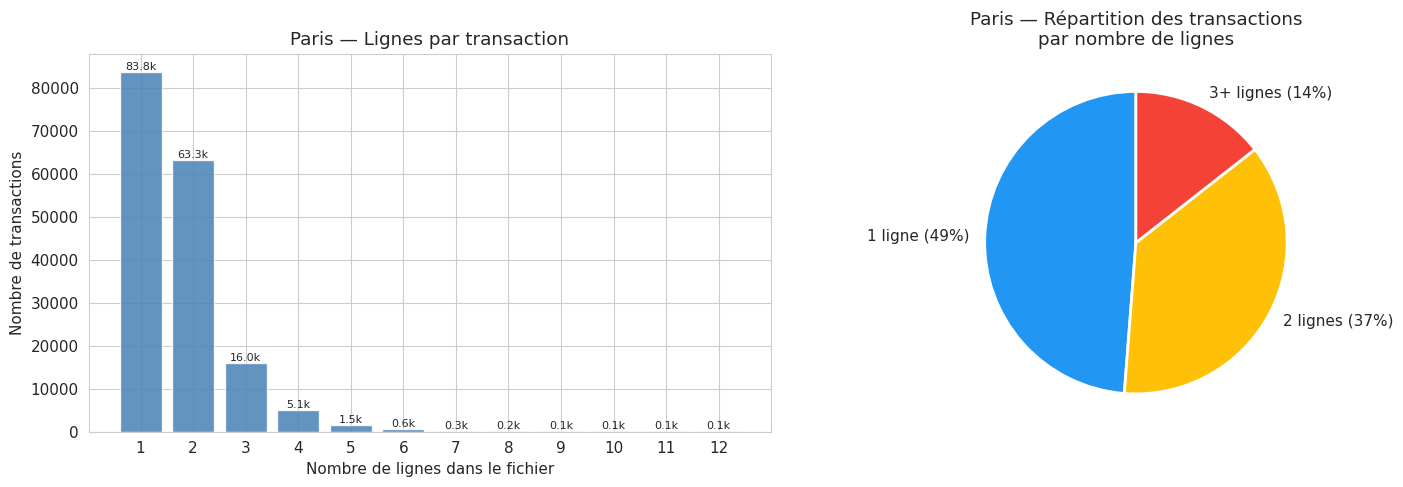

48.8% des transactions → 1 seule ligne  (simple)
36.8% des transactions → 2 lignes       (ex: appart + cave)
14.4% des transactions → 3+ lignes      (plusieurs locaux / natures de culture)


In [ ]:
# Distribution du nombre de lignes par transaction à Paris
rows_dist = key_counts.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barplot
display_rows = rows_dist[rows_dist.index <= 12]
bars = axes[0].bar(display_rows.index.astype(str), display_rows.values,
                   color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Nombre de lignes dans le fichier')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_title('Paris — Lignes par transaction')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h,
                     f'{h/1e3:.1f}k', ha='center', va='bottom', fontsize=8)

# Camembert simplifié
pct_1    = rows_dist.get(1, 0) / len(key_counts) * 100
pct_2    = rows_dist.get(2, 0) / len(key_counts) * 100
pct_3p   = 100 - pct_1 - pct_2
labels   = [f'1 ligne ({pct_1:.0f}%)', f'2 lignes ({pct_2:.0f}%)', f'3+ lignes ({pct_3p:.0f}%)']
vals     = [rows_dist.get(1, 0), rows_dist.get(2, 0),
             sum(v for k, v in rows_dist.items() if k >= 3)]
axes[1].pie(vals, labels=labels, autopct='', startangle=90,
            colors=['#2196F3', '#FFC107', '#F44336'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Paris — Répartition des transactions\npar nombre de lignes')

plt.tight_layout()
plt.show()

print(f'{pct_1:.1f}% des transactions → 1 seule ligne  (simple)')
print(f'{pct_2:.1f}% des transactions → 2 lignes       (ex: appart + cave)')
print(f'{pct_3p:.1f}% des transactions → 3+ lignes      (plusieurs locaux / natures de culture)')


### Stratégie : comment agréger correctement ?

On distingue deux types de champs dans DVF :

| Type de champ | Exemples | Comment agréger |
|---|---|---|
| **Champ transaction** — identique sur toutes les lignes | `valeur_fonciere`, `date_mutation`, adresse | `first` |
| **Champ local** — varie selon le local concerné | `surface_reelle_bati`, `nombre_pieces_principales` | `sum` |

On va d'abord appliquer cette logique **sur Paris uniquement**,
vérifier que le résultat est cohérent, puis étendre à toute l'IDF.

In [ ]:
# ─── Pipeline de nettoyage sur Paris uniquement ──────────────────────────────

p = paris.copy()


#-------------------------------------------------------------------------------------------------------
################################################# TO DO ################################################
# 1. Conversions de types

# Step 1 : Convertir la valeur_fonciere dans en float (attention: il s'agissait d'un string avec des virgules).
p['valeur_fonciere']           = ...
# Step 2 : Convertir la 'surface_relle_bati', le 'nombre_pieces_principales', la 'surface_terrain' en format float.
p['surface_reelle_bati']       = ...
p['nombre_pieces_principales'] = ...
p['surface_terrain']           = ...
# Step 3 : Pour chaque colonne dont le nom contient 'surface_carrez', convertir les valeurs en float
# (attention: il faut faire la meme manipulation qu'en step 1).
...
# Step 4 : Convertir les valeurs de la colonne 'date_mutation' en datetime.
p['date_mutation'] = ...
#-------------------------------------------------------------------------------------------------------



#-------------------------------------------------------------------------------------------------------
################################################# TO DO ################################################
# 2. Filtres métier

# Step 1 : On ne souhaite garder que les mutations de type vente.
p = ...

# Step 2 : tx_dep correspond à l'ensemble de toutes toutes les mutations uniques (_key) associés à des dépendances (parkings, caves, etc.).
# (Nous aurons besoin de tx_dep par la suite)
tx_dep = ...

# Step 3 : On souhaite récupérer uniquement les mutations dont le code_type_local correspond à une maison ou un appartement (1, ou 2), et on fait une copie.
p = ...
#-------------------------------------------------------------------------------------------------------

# On créer une colonne "has_dependance" à l'aide de tx_dep pour permettre de savoir si une maison ou un appartement possède des dépendances.
p['has_dependance'] = p['_key'].isin(tx_dep)

# 3. Agrégation en DEUX PASSES pour gérer le cas n×p
CARREZ = [c for c in p.columns if 'surface_carrez' in c]
FIRST  = ['date_mutation', 'valeur_fonciere', 'nature_mutation',
           'adresse_nom_voie', 'adresse_numero', 'code_postal', 'nom_commune',
           'code_departement', 'code_commune', 'nombre_lots',
           'code_type_local', 'type_local', 'annee']

# Passe A : champs transaction (first)
p_tx = p.groupby('_key').agg(
    {**{c: 'first' for c in FIRST if c in p.columns},
     'has_dependance': 'any'}
)

# Passe B : surfaces bâties — dédupliquer par local (lot1_no + type)
# Un local = même lot1_no (si disponible) + même type + même surface réelle
_local_key = ['_key', 'lot1_numero', 'code_type_local', 'surface_reelle_bati']
_local_key = [c for c in _local_key if c in p.columns]
p_locals = p.drop_duplicates(subset=_local_key, keep='first')
p_surf = p_locals.groupby('_key')[['surface_reelle_bati', 'nombre_pieces_principales'] + CARREZ].sum()

# Passe C : surface terrain — dédupliquer par nature de culture
_terrain_key = ['_key', 'code_nature_culture']
_terrain_key = [c for c in _terrain_key if c in p.columns]
p_terrain = p.drop_duplicates(subset=_terrain_key, keep='first')
p_terr = p_terrain.groupby('_key')['surface_terrain'].sum()

# Assemblage
paris_agg = p_tx.join(p_surf).join(p_terr).reset_index(drop=True)
paris_agg = paris_agg[
    (paris_agg['surface_reelle_bati'] > 0) & (paris_agg['valeur_fonciere'] > 0)
].copy()
paris_agg['prix_m2'] = paris_agg['valeur_fonciere'] / paris_agg['surface_reelle_bati']

print(f'Paris — Résultat :')
print(f'  Lignes brutes        : {len(paris):,}')
print(f'  Transactions propres : {len(paris_agg):,}')
print(f'  Réduction            : {(1 - len(paris_agg)/len(paris))*100:.1f}%')


NameError: name 'paris' is not defined

Statistiques Paris — transactions agrégées :
       valeur_fonciere  surface_reelle_bati     prix_m2  nombre_pieces_principales
count         129516.0             129516.0    129516.0                   129516.0
mean          722447.0                 60.0     11350.0                        3.0
std          3218301.0                 80.0     51992.0                        3.0
min                1.0                  2.0         0.0                        0.0
25%           262500.0                 28.0      8665.0                        1.0
50%           429000.0                 45.0     10385.0                        2.0
75%           730000.0                 70.0     12245.0                        3.0
max        606210300.0               7434.0  15937500.0                      228.0


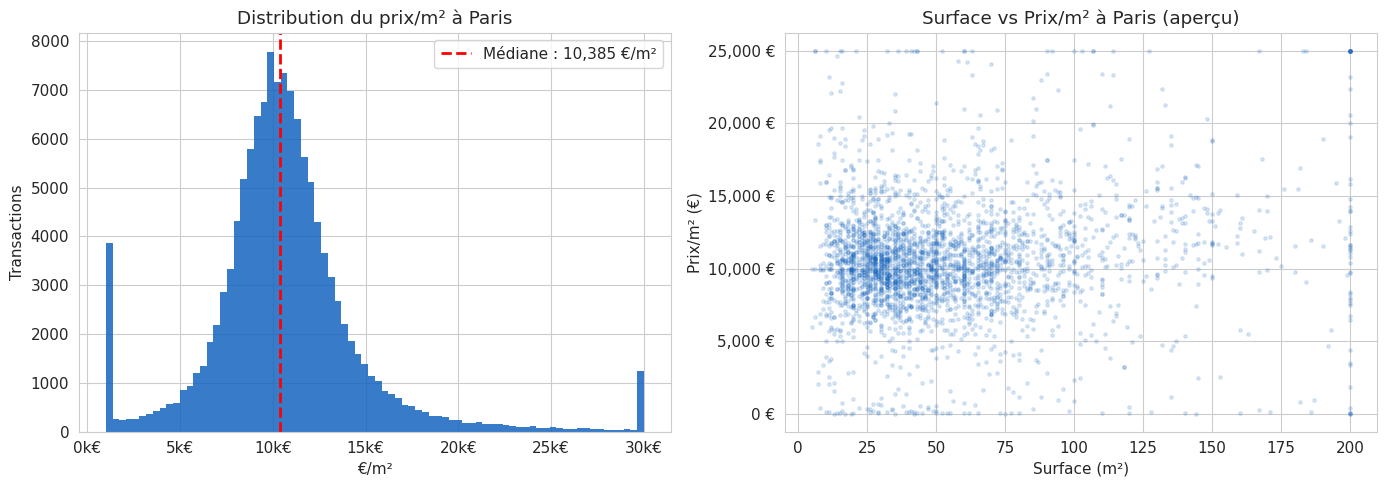


Check : médiane prix/m² Paris ≈ 10,385 €/m²
→ Cohérent avec les prix du marché parisien (~10 000 €/m²)

La structure est comprise. On applique maintenant la même logique à toute l'IDF.


In [ ]:
# ─── Vérification rapide sur Paris ───────────────────────────────────────────

print('Statistiques Paris — transactions agrégées :')
print(paris_agg[['valeur_fonciere', 'surface_reelle_bati', 'prix_m2',
                   'nombre_pieces_principales']]
      .describe(percentiles=[.25, .5, .75]).round(0).to_string())

# Sanity check : distribution du prix/m2 à Paris
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

paris_clean_pm2 = paris_agg['prix_m2'].clip(1000, 30000)
axes[0].hist(paris_clean_pm2, bins=80, color='#1565C0', edgecolor='none', alpha=0.85)
axes[0].axvline(paris_agg['prix_m2'].median(), color='red', lw=2, ls='--',
                label=f'Médiane : {paris_agg["prix_m2"].median():,.0f} €/m²')
axes[0].set_title('Distribution du prix/m² à Paris')
axes[0].set_xlabel('€/m²')
axes[0].set_ylabel('Transactions')
axes[0].xaxis.set_major_formatter(fmt_keur)
axes[0].legend()

# Scatter surface vs prix
sample_p = paris_agg.sample(min(3000, len(paris_agg)), random_state=42)
axes[1].scatter(sample_p['surface_reelle_bati'].clip(0, 200),
                sample_p['prix_m2'].clip(0, 25000),
                alpha=0.15, s=6, color='#1565C0')
axes[1].set_xlabel('Surface (m²)')
axes[1].set_ylabel('Prix/m² (€)')
axes[1].set_title('Surface vs Prix/m² à Paris (aperçu)')
axes[1].yaxis.set_major_formatter(fmt_euro)

plt.tight_layout()
plt.show()

print(f'\nCheck : médiane prix/m² Paris ≈ {paris_agg["prix_m2"].median():,.0f} €/m²')
print('→ Cohérent avec les prix du marché parisien (~10 000 €/m²)')
print('\nLa structure est comprise. On applique maintenant la même logique à toute l\'IDF.')


---
### → On passe à l'Île-de-France complète

Le pipeline qu'on vient de valider sur Paris s'applique identiquement à `df_raw` complet
(8 départements, toutes années). Les sections suivantes font exactement ça,
en ajoutant les raffinements métier (outliers par zone, features géographiques, etc.).

**Nettoyage des variables temporaires :**

In [ ]:
# Nettoyage des colonnes temporaires créées pendant l'exploration
if '_key' in paris.columns:
    paris.drop(columns=['_key'], inplace=True, errors='ignore')
if '_temp_key' in df_raw.columns:
    df_raw.drop(columns=['_temp_key'], inplace=True, errors='ignore')

print('Prêt pour le pipeline complet IDF → Section 5')
print(f'df_raw : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')


Prêt pour le pipeline complet IDF → Section 5
df_raw : 1,984,815 lignes × 32 colonnes


---
## 5. Nettoyage de base & conversions de types <a id='5'></a>

Le fichier DVF brut contient des données au **format texte** avec des spécificités françaises :
- La virgule comme séparateur décimal : `"580000,00"` au lieu de `580000.0`
- Les dates au format JJ/MM/AAAA
- Les nombres entiers encodés comme chaînes de caractères

Il faut convertir correctement avant tout traitement numérique.

In [ ]:
df = df_raw.copy()

# ─── 1. Valeur foncière : virgule → point, puis float ─────────────────────────
print('Avant conversion :', df['valeur_fonciere'].head(3).tolist())

df['valeur_fonciere'] = (
    df['valeur_fonciere']
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

print('Après conversion :', df['valeur_fonciere'].head(3).tolist())
print(f'  NaN créés : {df["valeur_fonciere"].isnull().sum():,}')

Avant conversion : ['1480000', '1480000', '1480000']
Après conversion : [1480000.0, 1480000.0, 1480000.0]
  NaN créés : 17,485


In [ ]:
# ─── 2. Surfaces Carrez (format comma) ────────────────────────────────────────
carrez_cols = [c for c in df.columns if 'surface_carrez' in c]
for col in carrez_cols:
    df[col] = (
        df[col]
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
print(f'Colonnes Carrez converties : {carrez_cols}')

# ─── 3. Colonnes entières ─────────────────────────────────────────────────────
int_cols = ['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'nombre_lots']
for col in [c for c in int_cols if c in df.columns]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f'Colonnes numériques converties : {int_cols}')

# ─── 4. Dates ─────────────────────────────────────────────────────────────────
# Format DVF géolocalisé : AAAA-MM-JJ
df['date_mutation'] = pd.to_datetime(df['date_mutation'], format='%Y-%m-%d', errors='coerce')
print(f'\ndate_mutation : {df["date_mutation"].dtype}')
print(f'  Plage : {df["date_mutation"].min().date()} → {df["date_mutation"].max().date()}')

# ─── 5. Vérification ──────────────────────────────────────────────────────────
print('\nTypes après conversion :')
key_types = ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales',
             'date_mutation', 'lot1_surface_carrez']
for col in [c for c in key_types if c in df.columns]:
    print(f'  {col:<30s} → {str(df[col].dtype)}')

Colonnes Carrez converties : ['lot1_surface_carrez', 'lot2_surface_carrez', 'lot3_surface_carrez', 'lot4_surface_carrez', 'lot5_surface_carrez']
Colonnes numériques converties : ['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'nombre_lots']

date_mutation : datetime64[ns]
  Plage : 2021-01-01 → 2024-12-31

Types après conversion :
  valeur_fonciere                → float64
  surface_reelle_bati            → float64
  nombre_pieces_principales      → float64
  date_mutation                  → datetime64[ns]
  lot1_surface_carrez            → float64


---
## 6. Filtrage métier <a id='6'></a>

Avant d'agréger, on filtre pour ne garder que les données pertinentes pour notre objectif :
**prédire les prix immobiliers résidentiels**.

### Filtres à appliquer

1. **Nature de la mutation** : garder uniquement les `Vente` simples
   - VEFA (vente sur plan) : prix incomplet à la date de la vente
   - Adjudication, échange : logiques de prix différentes

2. **Type de local** : garder `Maison` (1) et `Appartement` (2)
   - Dépendances (3) : caves, garages → pas de logement
   - Locaux industriels/commerciaux (4) : hors scope
   - `NaN` : souvent des terrains nus

In [ ]:
# ─── Filtre 1 : Nature de la mutation ─────────────────────────────────────────
print('=== Répartition AVANT filtrage ===')
print(df['nature_mutation'].value_counts(dropna=False).to_string())

n_before = len(df)
df = df[df['nature_mutation'] == 'Vente'].copy()

print(f'\n→ Après filtre "Vente" : {len(df):,} lignes '
      f'(supprimées : {n_before - len(df):,}, {(n_before - len(df))/n_before*100:.1f}%)')

=== Répartition AVANT filtrage ===
nature_mutation
Vente                                 1724525
Vente en l'état futur d'achèvement     238679
Echange                                  9144
Adjudication                             6987
Vente terrain à bâtir                    2956
Expropriation                            2524

→ Après filtre "Vente" : 1,724,525 lignes (supprimées : 260,290, 13.1%)


In [ ]:
# ─── Filtre 2 : Composition des transactions ────────────────────────────────
# Avant de filtrer les lignes, on analyse la COMPOSITION de chaque transaction.
# Objectif : ne garder que les ventes portant sur 1 seul bien résidentiel.

# On utilise id_mutation comme clé — c'est l'identifiant officiel DVF.
# Construire une clé ad-hoc à partir de l'adresse serait faux : un immeuble
# peut avoir des lots à plusieurs numéros de rue différents (ex. 28, 72, 82,
# 86 RUE DANTON → même id_mutation, adresses_numero différents).
_dedup_key = [c for c in ['id_mutation', 'lot1_numero', 'code_type_local',
                           'surface_reelle_bati'] if c in df.columns]

# ── Distribution des types de local ──────────────────────────────────────────
print('=== Types de local (toutes lignes) ===')
tc = df['type_local'].value_counts(dropna=False)
tc.index = tc.index.fillna('NaN (terrain/nature culture)')
for t, n in tc.items():
    print(f'  {str(t):<40s} {n:>10,}  ({n/len(df)*100:5.1f}%)')

# ── Problème 1 : transactions avec un local commercial ───────────────────────
commercial_tx = set(df.loc[df['code_type_local'] == '4', 'id_mutation'])
print(f'\n→ Transactions contenant ≥1 local commercial : {len(commercial_tx):,}')

SHOW_COLS = ['date_mutation', 'adresse_numero', 'adresse_nom_voie',
             'code_type_local', 'type_local', 'surface_reelle_bati',
             'lot1_numero', 'lot1_surface_carrez', 'code_nature_culture']

ex_com = df[df['id_mutation'] == list(commercial_tx)[0]][SHOW_COLS].reset_index(drop=True)
print('\nExemple — transaction avec local commercial :')
display(ex_com)

# ── Problème 2 : transactions avec plusieurs locaux résidentiels ─────────────
# Spot : compter les locaux résidentiels distincts (dédup n×p par lot1_numero)
_res = df[df['code_type_local'].isin(['1', '2'])]
n_res_per_tx = _res.drop_duplicates(subset=_dedup_key).groupby('id_mutation').size()
multi_res_tx = set(n_res_per_tx[n_res_per_tx > 1].index)
print(f'\n→ Transactions avec plusieurs locaux résidentiels : {len(multi_res_tx):,}')
print('  Distribution du nb de locaux résidentiels par transaction :')
print(n_res_per_tx.value_counts().sort_index().head(6).to_string())

ex_multi = df[df['id_mutation'] == list(multi_res_tx)[0]][SHOW_COLS].reset_index(drop=True)
print('\nExemple — vente multi-résidentielle (immeuble/lot) :')
display(ex_multi)


=== Types de local (toutes lignes) ===
  Dépendance                                  726,699  ( 42.1%)
  Appartement                                 510,345  ( 29.6%)
  Maison                                      209,052  ( 12.1%)
  NaN (terrain/nature culture)                197,267  ( 11.4%)
  Local industriel. commercial ou assimilé     81,162  (  4.7%)

→ Transactions contenant ≥1 local commercial : 44,250

Exemple — transaction avec local commercial :


,date_mutation,adresse_numero,adresse_nom_voie,code_type_local,type_local,surface_reelle_bati,lot1_numero,lot1_surface_carrez,code_nature_culture
0,2021-10-21,106,RUE DU LIEUTENANT PETIT LEROY,4,Local industriel. commercial ou assimilé,2133.0,NaN,NaN,S



→ Transactions avec plusieurs locaux résidentiels : 23,291
  Distribution du nb de locaux résidentiels par transaction :
1    565701
2     16279
3      2716
4      1240
5       739
6       522

Exemple — vente multi-résidentielle (immeuble/lot) :


,date_mutation,adresse_numero,adresse_nom_voie,code_type_local,type_local,surface_reelle_bati,lot1_numero,lot1_surface_carrez,code_nature_culture
0,2023-12-15,10,RUE MAURICE CHEVALIER,1,Maison,424.0,NaN,NaN,S
1,2023-12-15,10,RUE MAURICE CHEVALIER,1,Maison,64.0,NaN,NaN,S
2,2023-12-15,NaN,PARC DE MARNES,NaN,NaN,NaN,NaN,NaN,AG


In [ ]:
# ─── Filtrage + features dépendances ────────────────────────────────────────
# Règle retenue :
#   ✓ 1 appartement  + N dépendances (caves, parkings)  → OK
#   ✓ 1 maison       + N dépendances + terrain/jardin   → OK
#   ✗ local commercial présent dans la même transaction → exclu
#   ✗ plusieurs locaux résidentiels (immeuble, lot)     → exclu

exclude_tx = commercial_tx | multi_res_tx
valid_tx   = set(df['id_mutation'].unique()) - exclude_tx
n_tx_total = df['id_mutation'].nunique()

print(f'Transactions totales            : {n_tx_total:,}')
print(f'  avec local commercial         : {len(commercial_tx):,}')
print(f'  multi-résidentielles          : {len(multi_res_tx):,}')
print(f'  (les deux à la fois)          : {len(commercial_tx & multi_res_tx):,}')
print(f'Conservées                      : {len(valid_tx):,}  '
      f'({len(valid_tx)/n_tx_total*100:.1f}%)')

df = df[df['id_mutation'].isin(valid_tx)].copy()

# ── Features dépendances : calculées AVANT de supprimer les lignes type=3 ────
_dep = df[df['code_type_local'] == '3'].drop_duplicates(subset=_dedup_key)

if len(_dep) > 0:
    ex_dep_key = _dep['id_mutation'].iloc[0]
    ex_dep = df[df['id_mutation'] == ex_dep_key][SHOW_COLS].reset_index(drop=True)
    print('\nExemple — appartement vendu avec sa cave/parking :')
    display(ex_dep)

dep_agg = (
    _dep.groupby('id_mutation')
    .agg(nb_dependances      = ('code_type_local',    'count'),
         surface_dependances = ('surface_reelle_bati', 'sum'))
)
df = df.merge(dep_agg, on='id_mutation', how='left')
df['nb_dependances']      = df['nb_dependances'].fillna(0).astype(int)
df['surface_dependances'] = df['surface_dependances'].fillna(0.0)

print(f'\nnb_dependances (par transaction unique) :')
print(df.drop_duplicates('id_mutation')['nb_dependances']
        .value_counts().sort_index().head(6).to_string())

# ── Filtre final : ne garder que les lignes résidentielles ───────────────────
n_avant = len(df)
df = df[df['code_type_local'].isin(['1', '2'])].copy()
print(f'\nLignes résidentielles restantes : {len(df):,}  '
      f'(supprimées : {n_avant - len(df):,})')


Transactions totales            : 721,078
  avec local commercial         : 44,250
  multi-résidentielles          : 23,291
  (les deux à la fois)          : 3,704
Conservées                      : 657,241  (91.1%)

Exemple — appartement vendu avec sa cave/parking :


,date_mutation,adresse_numero,adresse_nom_voie,code_type_local,type_local,surface_reelle_bati,lot1_numero,lot1_surface_carrez,code_nature_culture
0,2021-01-05,4,RUE DE LA BIENFAISANCE,2,Appartement,111.0,13,116.01,NaN
1,2021-01-05,4,RUE DE LA BIENFAISANCE,3,Dépendance,NaN,13,116.01,NaN
2,2021-01-05,4,RUE DE LA BIENFAISANCE,3,Dépendance,NaN,13,116.01,NaN
3,2021-01-05,4,RUE DE LA BIENFAISANCE,3,Dépendance,NaN,16,5.61,NaN



nb_dependances (par transaction unique) :
nb_dependances
0    247758
1    299269
2     96952
3     11120
4      1153
5       345

Lignes résidentielles restantes : 578,718  (supprimées : 778,911)


---
## 7. Agrégation par transaction <a id='7'></a>

### Stratégie d'agrégation

| Type de champ | Exemples | Comment agréger |
|---|---|---|
| **Transaction** — identique sur toutes les lignes | `valeur_fonciere`, `date_mutation`, adresse | `first` |
| **Local** — une valeur par bâtiment/local | `surface_reelle_bati`, `nombre_pieces_principales` | `sum` après dédup locale |
| **Terrain** — une valeur par nature de culture | `surface_terrain` | `sum` après dédup terrain |

### Pourquoi deux passes de déduplication ?

À cause du cas **n × p** vu en section 3 (n locaux × p natures de culture).
On utilise `lot1_numero` comme identifiant de local pour la passe locale,
et `code_nature_culture` pour la passe terrain.

```
df_res  →  [dédup sur lot1_no + code_type_local]  →  sum(surface_reelle_bati, pièces)
        →  [dédup sur code_nature_culture       ]  →  sum(surface_terrain)
        →  [first sur champs transaction        ]  →  valeur_fonciere, date, adresse...
```


In [ ]:
# ─── Identifiant de transaction ─────────────────────────────────────────────
# id_mutation est l'identifiant officiel DVF — unique par vente.
# On l'alias en transaction_id pour cohérence avec les cellules d'agrégation.

df['transaction_id'] = df['id_mutation']

# df_res : dataset résidentiel filtré, prêt pour l'agrégation
df_res = df.copy()

rows_per_tx = df_res.groupby('transaction_id').size()
print(f'Transactions : {rows_per_tx.shape[0]:,}')
print(f'Lignes       : {len(df_res):,}')
print(f'Ratio        : {len(df_res)/rows_per_tx.shape[0]:.2f} lignes/tx en moyenne')


Transactions : 557,561
Lignes       : 578,718
Ratio        : 1.04 lignes/tx en moyenne


In [ ]:
# ─── Agrégation IDF — deux passes pour respecter la structure n×p ─────────────

FIRST_COLS = [
    'date_mutation', 'nature_mutation', 'valeur_fonciere',
    'adresse_numero', 'adresse_nom_voie', 'code_postal', 'nom_commune',
    'code_departement', 'code_commune', 'nombre_lots',
    'code_type_local', 'type_local', 'annee',
    'nb_dependances', 'surface_dependances',
    'latitude', 'longitude',
]
CARREZ_COLS = [c for c in df_res.columns if 'surface_carrez' in c]

# ── Passe A : champs transaction (répétés à l'identique) ──────────────────────
tx_agg = df_res.groupby('transaction_id').agg(
    {c: 'first' for c in FIRST_COLS if c in df_res.columns}
)

# ── Passe B : surfaces bâties — dédup par local ────────────────────────────────
# Identifiant de local : lot1_no + code_type_local + surface_reelle_bati
# Élimine les doublons dus au produit cartésien n×p
_local_id = [c for c in ['transaction_id', 'lot1_numero', 'code_type_local',
                          'surface_reelle_bati'] if c in df_res.columns]
df_locals = df_res.drop_duplicates(subset=_local_id, keep='first')

local_sum_cols = ['surface_reelle_bati', 'nombre_pieces_principales'] + CARREZ_COLS
surf_agg = df_locals.groupby('transaction_id')[
    [c for c in local_sum_cols if c in df_locals.columns]
].sum(min_count=1)  # min_count=1 : NaN si aucune valeur connue (pas 0)

print(f'Locaux après dédup n×p : {len(df_locals):,} (était {len(df_res):,})')
print(f'Réduction              : {(1-len(df_locals)/len(df_res))*100:.1f}%')

# ── Passe C : surface terrain — dédup par nature de culture ───────────────────
_terrain_id = [c for c in ['transaction_id', 'code_nature_culture']
               if c in df_res.columns]
df_terrain = df_res.drop_duplicates(subset=_terrain_id, keep='first')
terr_agg   = df_terrain.groupby('transaction_id')['surface_terrain'].sum(min_count=1)

# ── Assemblage ─────────────────────────────────────────────────────────────────
df_agg = tx_agg.join(surf_agg).join(terr_agg.rename('surface_terrain')).reset_index()

print(f'\nRésultat :')
print(f'  Lignes avant  : {len(df_res):,}')
print(f'  Transactions  : {len(df_agg):,}')
print(f'  Réduction     : {(1-len(df_agg)/len(df_res))*100:.1f}%')
print(f'\nnb_dependances :')
print(df_agg['nb_dependances'].value_counts().sort_index().head(6).to_string())


Locaux après dédup n×p : 557,561 (était 578,718)
Réduction              : 3.7%

Résultat :
  Lignes avant  : 578,718
  Transactions  : 557,561
  Réduction     : 3.7%

nb_dependances :
nb_dependances
0    206027
1    247669
2     92520
3     10265
4       819
5       165


---
## 8. Calcul du prix/m² & filtrage des outliers <a id='8'></a>

### La variable cible : le prix au mètre carré

$$\text{prix\_m2} = \frac{\text{valeur\_fonciere}}{\text{surface\_reelle\_bati}}$$

Deux étapes avant d'utiliser cette variable :
1. **Détection des aberrations** — identifier les valeurs extrêmes et comprendre leur origine
2. **Filtrage statistique** — couper les queues *par groupe* (zone × type), en exploitant le fait que log₁₀(prix/m²) suit une loi quasi-gaussienne par groupe


In [ ]:
# ─── Filtres préalables + calcul du prix/m² ─────────────────────────────────
#-------------------------------------------------------------------------------------------------------
################################################# TO DO ################################################
# Nettoyer la dataframe df_agg :
# - filtrer en ne récupérant que les valeurs qui ont du sens (exemple : valeur_fonciere <=0 n'a pas de sens métier)
# - filtrer en ne récupérant que les valeurs non NaN pour la latitude et la longitude
df_clean = ...
#-------------------------------------------------------------------------------------------------------

print(f'Conservées : {len(df_clean):,}')
print(f'Supprimées : {len(df_agg) - len(df_clean):,}  '
      f'({(len(df_agg)-len(df_clean))/len(df_agg)*100:.1f}%)')
print(f'  surface/prix nul : '
      f'{(~((df_agg.surface_reelle_bati>0)&(df_agg.valeur_fonciere>0))).sum():,}')
print(f'  lat/lon manquant : {df_agg.latitude.isna().sum():,}')

df_clean['prix_m2'] = df_clean['valeur_fonciere'] / df_clean['surface_reelle_bati']

print('\nStatistiques prix/m² AVANT filtrage :')
print(df_clean['prix_m2'].describe().apply(lambda x: f'{x:,.0f}').to_string())


Conservées : 551,142
Supprimées : 6,419  (1.2%)
  surface/prix nul : 226
  lat/lon manquant : 6,195

Statistiques prix/m² AVANT filtrage :
count      551,142
mean         5,945
std          6,886
min              0
25%          3,247
50%          4,702
75%          8,076
max      3,829,508


In [ ]:
# ─── Premier réflexe : regarder les extrêmes ────────────────────────────────
SHOW = ['date_mutation', 'valeur_fonciere', 'adresse_numero', 'adresse_nom_voie',
        'nom_commune', 'type_local', 'surface_reelle_bati', 'prix_m2']

print('=== 5 prix/m² les plus ÉLEVÉS ===')
#-------------------------------------------------------------------------------------------------------
################################################# TO DO ################################################
# Step 1 : Afficher avec la fonction display() les 5 valeurs prix_m2 les plus élevées (nlargest)
display(...)

print('\n=== 5 prix/m² les plus BAS ===')
# Step 2 : Afficher avec la fonction display() les 5 valeurs prix_m2 les plus faibles (nsmallest)
display(...)
#-------------------------------------------------------------------------------------------------------


#### Investiguer un point aberrant

Quand on repère un prix/m² suspect, la bonne démarche est de **remonter aux données brutes** pour comprendre l'origine : erreur de saisie de surface ? transaction hors périmètre ? bien réel mais exceptionnel ?


In [ ]:
# ─── Remonter aux lignes brutes du cas le plus aberrant ─────────────────────
bad = df_clean.loc[df_clean['prix_m2'].idxmax()]
print(f'→ {bad["adresse_numero"]} {bad["adresse_nom_voie"]}, {bad["nom_commune"]}')
print(f'  valeur_fonciere    : {bad["valeur_fonciere"]:,.0f} €')
print(f'  surface_reelle_bati: {bad["surface_reelle_bati"]:.1f} m²')
print(f'  prix/m²            : {bad["prix_m2"]:,.0f} €/m²')

# Retrouver toutes les lignes de cette transaction dans df_raw
# Lookup by id_mutation — reliable even when the same address has multiple transactions,
# and avoids comparing str (df_raw) vs Timestamp (df_clean).
raw_mask = df_raw['id_mutation'] == bad['transaction_id']
raw_cols = ['date_mutation', 'valeur_fonciere', 'adresse_numero', 'adresse_nom_voie',
            'code_type_local', 'type_local', 'surface_reelle_bati',
            'lot1_numero', 'lot1_surface_carrez', 'code_nature_culture']
display(df_raw[raw_mask][[c for c in raw_cols if c in df_raw.columns]].reset_index(drop=True))
print('\n→ La surface agrégée est-elle vraisemblable ? '
      'Combien de locaux ont été fusionnés ?')


→ 4 RUE DES HAUTES RAYES, Conflans-Sainte-Honorine
  valeur_fonciere    : 467,200,000 €
  surface_reelle_bati: 122.0 m²
  prix/m²            : 3,829,508 €/m²


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_type_local,type_local,surface_reelle_bati,lot1_numero,lot1_surface_carrez,code_nature_culture
0,2022-09-08,467200000,4,RUE DES HAUTES RAYES,1,Maison,122,NaN,NaN,S



→ La surface agrégée est-elle vraisemblable ? Combien de locaux ont été fusionnés ?


In [ ]:
# ─── Attribution des zones géographiques ────────────────────────────────────
ZONE_MAP = {
    '75': 'Paris',
    '92': 'Petite Couronne', '93': 'Petite Couronne', '94': 'Petite Couronne',
    '77': 'Grande Couronne', '78': 'Grande Couronne',
    '91': 'Grande Couronne', '95': 'Grande Couronne',
}
df_clean['zone'] = df_clean['code_departement'].map(ZONE_MAP)
print(df_clean.groupby(['zone', 'type_local']).size()
        .rename('n').reset_index().to_string(index=False))


           zone  type_local      n
Grande Couronne Appartement 117599
Grande Couronne      Maison 127801
          Paris Appartement 119982
          Paris      Maison    584
Petite Couronne Appartement 145453
Petite Couronne      Maison  39723


---
### Analyse de la distribution du prix/m²

Avant de filtrer, on comprend la **structure** de la distribution — ce qui détermine le bon niveau de coupure.


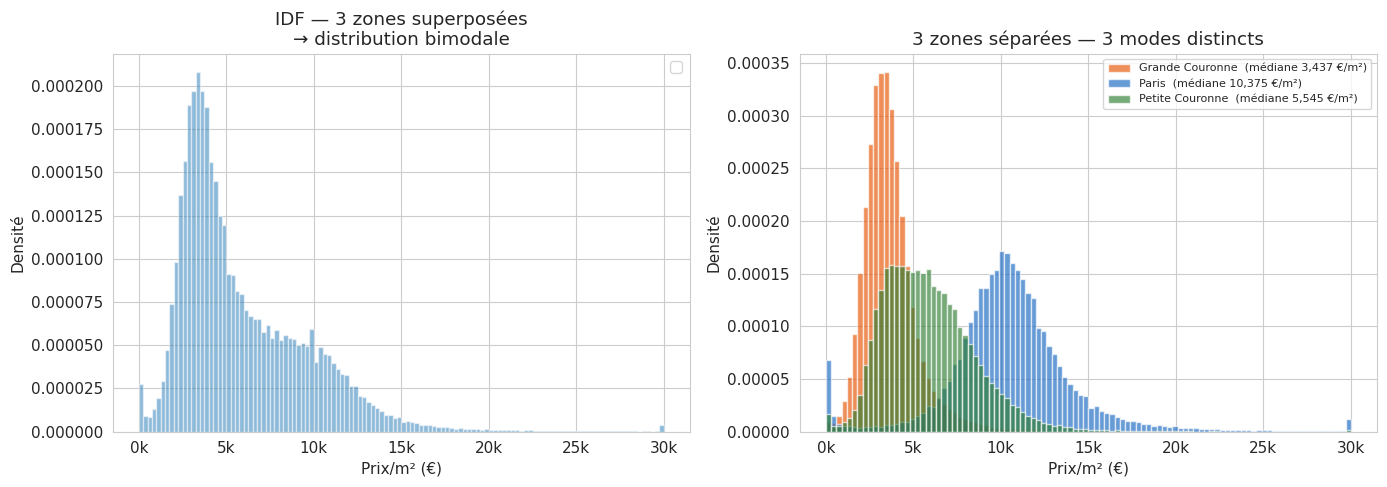

In [ ]:
# ─── Distribution brute IDF complète ────────────────────────────────────────
ZONE_COLORS = {'Paris': '#1565C0', 'Petite Couronne': '#2E7D32', 'Grande Couronne': '#E65100'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Toutes zones superposées → bimodalité
ax = axes[0]

ax.hist(df_clean['prix_m2'].clip(0, 30000), bins=120, alpha=0.5,
          density=True)
ax.set_title('IDF — 3 zones superposées\n→ distribution bimodale')
ax.set_xlabel('Prix/m² (€)')
ax.set_ylabel('Densité')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}k'))
ax.legend()

# Les 3 zones séparées — 3 modes distincts
ax = axes[1]
offsets = {'Paris': 0, 'Petite Couronne': -0.3, 'Grande Couronne': -0.6}
for zone, grp in df_clean.groupby('zone'):
    d = grp['prix_m2'].clip(0, 30000)
    ax.hist(d, bins=100, alpha=0.65, color=ZONE_COLORS[zone],
            label=f'{zone}  (médiane {d.median():,.0f} €/m²)', density=True)
ax.set_title('3 zones séparées — 3 modes distincts')
ax.set_xlabel('Prix/m² (€)')
ax.set_ylabel('Densité')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}k'))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# ─── Passage en log₁₀ ────────────────────────────────────────────────────────
# Pourquoi le log ?
# → Le prix immobilier suit une logique multiplicative : un bien vaut 2× plus
#   ou 2× moins, pas 200 k€ de plus ou de moins. L'échelle logarithmique
#   linéarise ces rapports et rend les distributions plus symétriques.
# → C'est la transformation standard en finance et en économie de l'immobilier.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for zone, grp in df_clean.groupby('zone'):
    ax.hist(grp['prix_m2'].clip(0, 15_000), bins=100, alpha=0.5,
            color=ZONE_COLORS[zone], label=zone, density=True)
ax.set_title('Échelle linéaire — queues longues,\ndistributions asymétriques')
ax.set_xlabel('Prix/m² (€)')
ax.set_ylabel('Densité')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}k'))
ax.legend(fontsize=8)

ax = axes[1]
for zone, grp in df_clean.groupby('zone'):
    ax.hist(np.log10(grp['prix_m2']), bins=80, alpha=0.5,
            color=ZONE_COLORS[zone], label=zone, density=True)
ax.set_title('Échelle log₁₀ — distributions plus symétriques,\n'
             'chaque zone quasi-gaussienne')
ax.set_xlabel('log₁₀(Prix/m²)')
ax.set_ylabel('Densité')
ax.set_xticks([2.5, 3.0, 3.5, 4.0, 4.5])
ax.set_xticklabels(['~300', '1k', '3k', '10k', '30k'])
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


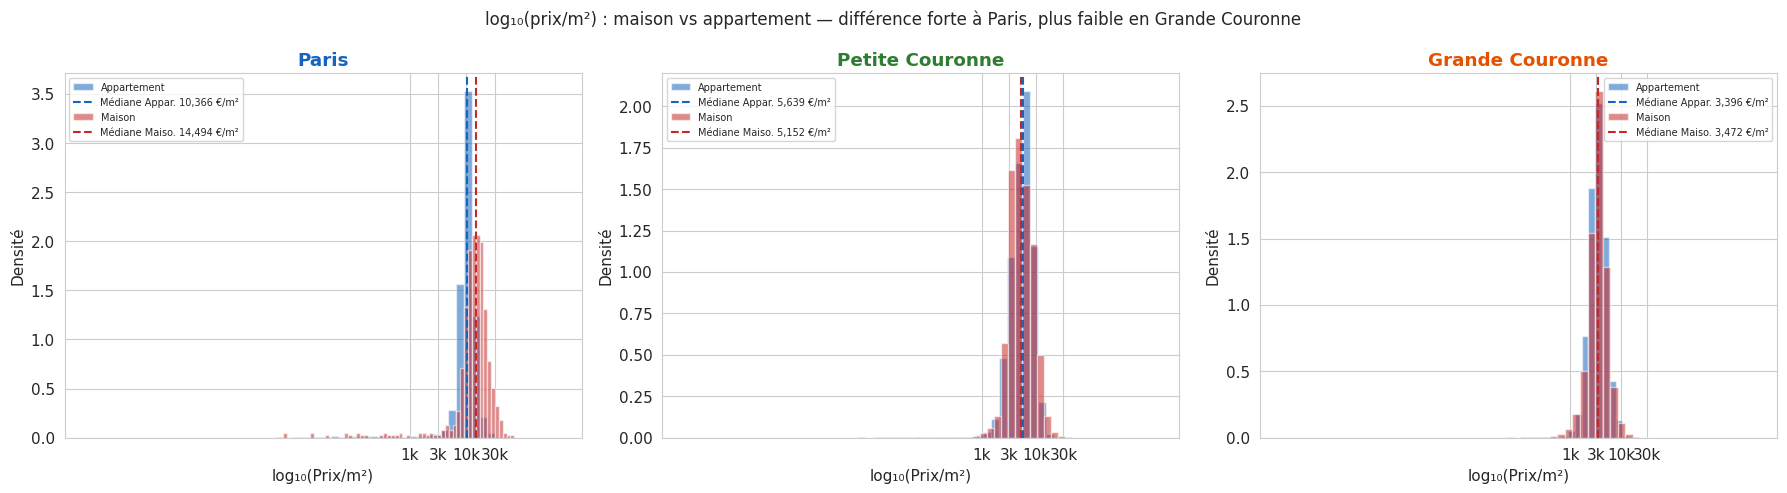

In [ ]:
# ─── Séparation maison / appartement ────────────────────────────────────────
# À Paris, maisons et appartements ont des marchés très différents.
# En Grande Couronne, la différence est moins marquée.

TYPE_COLORS = {'Appartement': '#1565C0', 'Maison': '#C62828'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'log₁₀(prix/m²) : maison vs appartement — '
    'différence forte à Paris, plus faible en Grande Couronne',
    fontsize=12
)

for ax, zone in zip(axes, ['Paris', 'Petite Couronne', 'Grande Couronne']):
    sub = df_clean[df_clean['zone'] == zone]
    for ttype, grp in sub.groupby('type_local'):
        lp = np.log10(grp['prix_m2'])
        ax.hist(lp, bins=60, alpha=0.55, density=True,
                color=TYPE_COLORS.get(ttype,'grey'), label=ttype)
        ax.axvline(lp.median(), color=TYPE_COLORS.get(ttype,'grey'),
                   ls='--', lw=1.5,
                   label=f'Médiane {ttype[:5]}. {10**lp.median():,.0f} €/m²')
    ax.set_title(zone, color=ZONE_COLORS[zone], fontweight='bold')
    ax.set_xlabel('log₁₀(Prix/m²)')
    ax.set_ylabel('Densité')
    ax.set_xticks([3.0, 3.5, 4.0, 4.5])
    ax.set_xticklabels(['1k', '3k', '10k', '30k'])
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


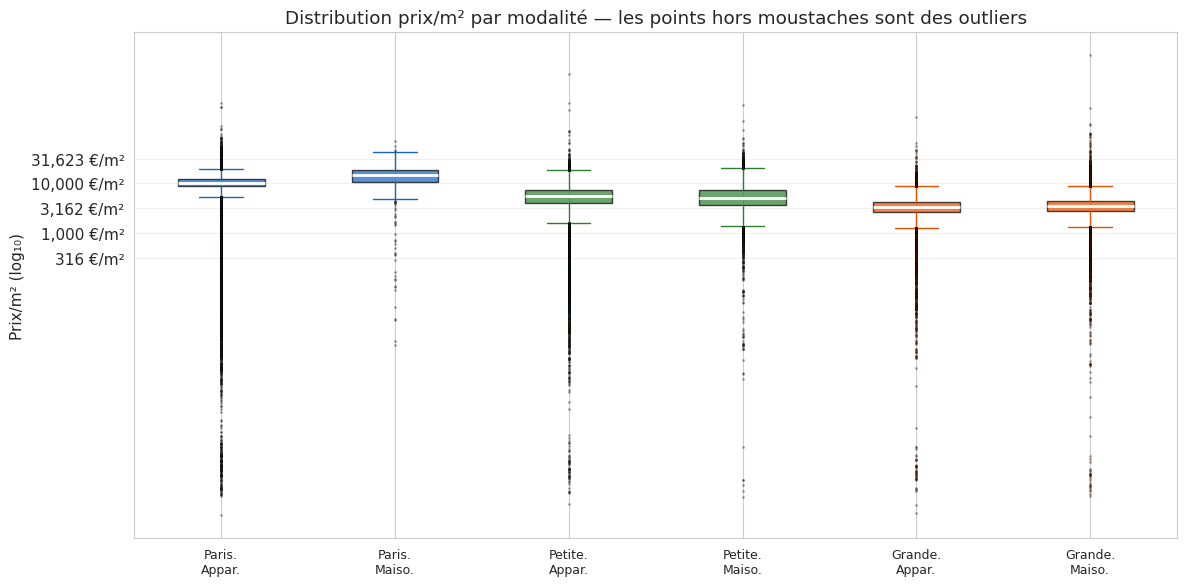

In [ ]:
# ─── Boxplots par modalité — visualiser les outliers ────────────────────────
ZONE_ORDER = ['Paris', 'Petite Couronne', 'Grande Couronne']
TYPE_ORDER = ['Appartement', 'Maison']

labels, data, colors = [], [], []
for zone in ZONE_ORDER:
    for ttype in TYPE_ORDER:
        sub = df_clean[(df_clean['zone']==zone) & (df_clean['type_local']==ttype)]
        if len(sub) < 10:
            continue
        labels.append(f'{zone[:6]}.\n{ttype[:5]}.')
        data.append(np.log10(sub['prix_m2']))
        colors.append(ZONE_COLORS[zone])

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color='white', lw=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
for whisker, c in zip(bp['whiskers'], [c for c in colors for _ in range(2)]):
    whisker.set_color(c)
for cap, c in zip(bp['caps'], [c for c in colors for _ in range(2)]):
    cap.set_color(c)
for flier, c in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(c)

ax.set_xticks(range(1, len(labels)+1))
ax.set_xticklabels(labels, fontsize=9)
yticks = [2.5, 3.0, 3.5, 4.0, 4.5]
ax.set_yticks(yticks)
ax.set_yticklabels([f'{10**t:,.0f} €/m²' for t in yticks])
ax.set_ylabel('Prix/m² (log₁₀)')
ax.set_title('Distribution prix/m² par modalité — les points hors moustaches sont des outliers')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ─── Filtrage par logique métier ─────────────────────────────────────────────
# On fixe des bornes économiquement raisonnables par groupe (€/m²).
# Ces valeurs correspondent aux seuils au-delà desquels on suspecte
# une erreur de saisie ou une transaction hors périmètre.

BOUNDS = {
    ('Paris',          'Appartement'): (5000, 20000),
    ('Paris',          'Maison')     : (5000, 30000),
    ('Petite Couronne','Appartement'): (1000, 20000),
    ('Petite Couronne','Maison')     : (  500,  20000),
    ('Grande Couronne','Appartement'): (  1000,  20000),
    ('Grande Couronne','Maison')     : (  500,  20000),
}

# Calcul des percentiles correspondants
rows = []
for (zone, ttype), (lo, hi) in BOUNDS.items():
    sub = df_clean[(df_clean['zone']==zone) & (df_clean['type_local']==ttype)]['prix_m2']
    if len(sub) == 0:
        continue
    pct_lo = (sub < lo).mean() * 100
    pct_hi = (sub > hi).mean() * 100
    rows.append({'Groupe': f'{zone} — {ttype}', 'n': len(sub),
                 'Borne basse': f'{lo:,} €/m²', 'P bas': f'P{pct_lo:.1f}',
                 'Borne haute': f'{hi:,} €/m²', 'P haut': f'P{100-pct_hi:.1f}',
                 '% exclus': f'{pct_lo+pct_hi:.1f}%'})

display(pd.DataFrame(rows).set_index('Groupe'))

# Application du filtre
def in_bounds(row):
    key = (row['zone'], row['type_local'])
    if key not in BOUNDS:
        return True
    lo, hi = BOUNDS[key]
    return lo <= row['prix_m2'] <= hi

mask = df_clean.apply(in_bounds, axis=1)
n_avant = len(df_clean)
df_clean = df_clean[mask].copy()

df_clean['log_prix_m2'] = np.log10(df_clean['prix_m2'])

print(f'Avant  : {n_avant:,}')
print(f'Après  : {len(df_clean):,}  ({len(df_clean)/n_avant*100:.1f}%)')
print(f'Exclus : {n_avant-len(df_clean):,}  ({(n_avant-len(df_clean))/n_avant*100:.1f}%)')


,n,Borne basse,P bas,Borne haute,P haut,% exclus
Groupe,,,,,,
Paris — Appartement,119982,"5,000 €/m²",P5.2,"20,000 €/m²",P98.2,7.0%
Paris — Maison,584,"5,000 €/m²",P6.5,"30,000 €/m²",P94.0,12.5%
Petite Couronne — Appartement,145453,"1,000 €/m²",P1.0,"20,000 €/m²",P99.9,1.1%
Petite Couronne — Maison,39723,500 €/m²,P0.3,"20,000 €/m²",P99.5,0.7%
Grande Couronne — Appartement,117599,"1,000 €/m²",P0.8,"20,000 €/m²",P100.0,0.8%
Grande Couronne — Maison,127801,500 €/m²,P0.4,"20,000 €/m²",P99.9,0.5%


Avant  : 551,142
Après  : 539,237  (97.8%)
Exclus : 11,905  (2.2%)


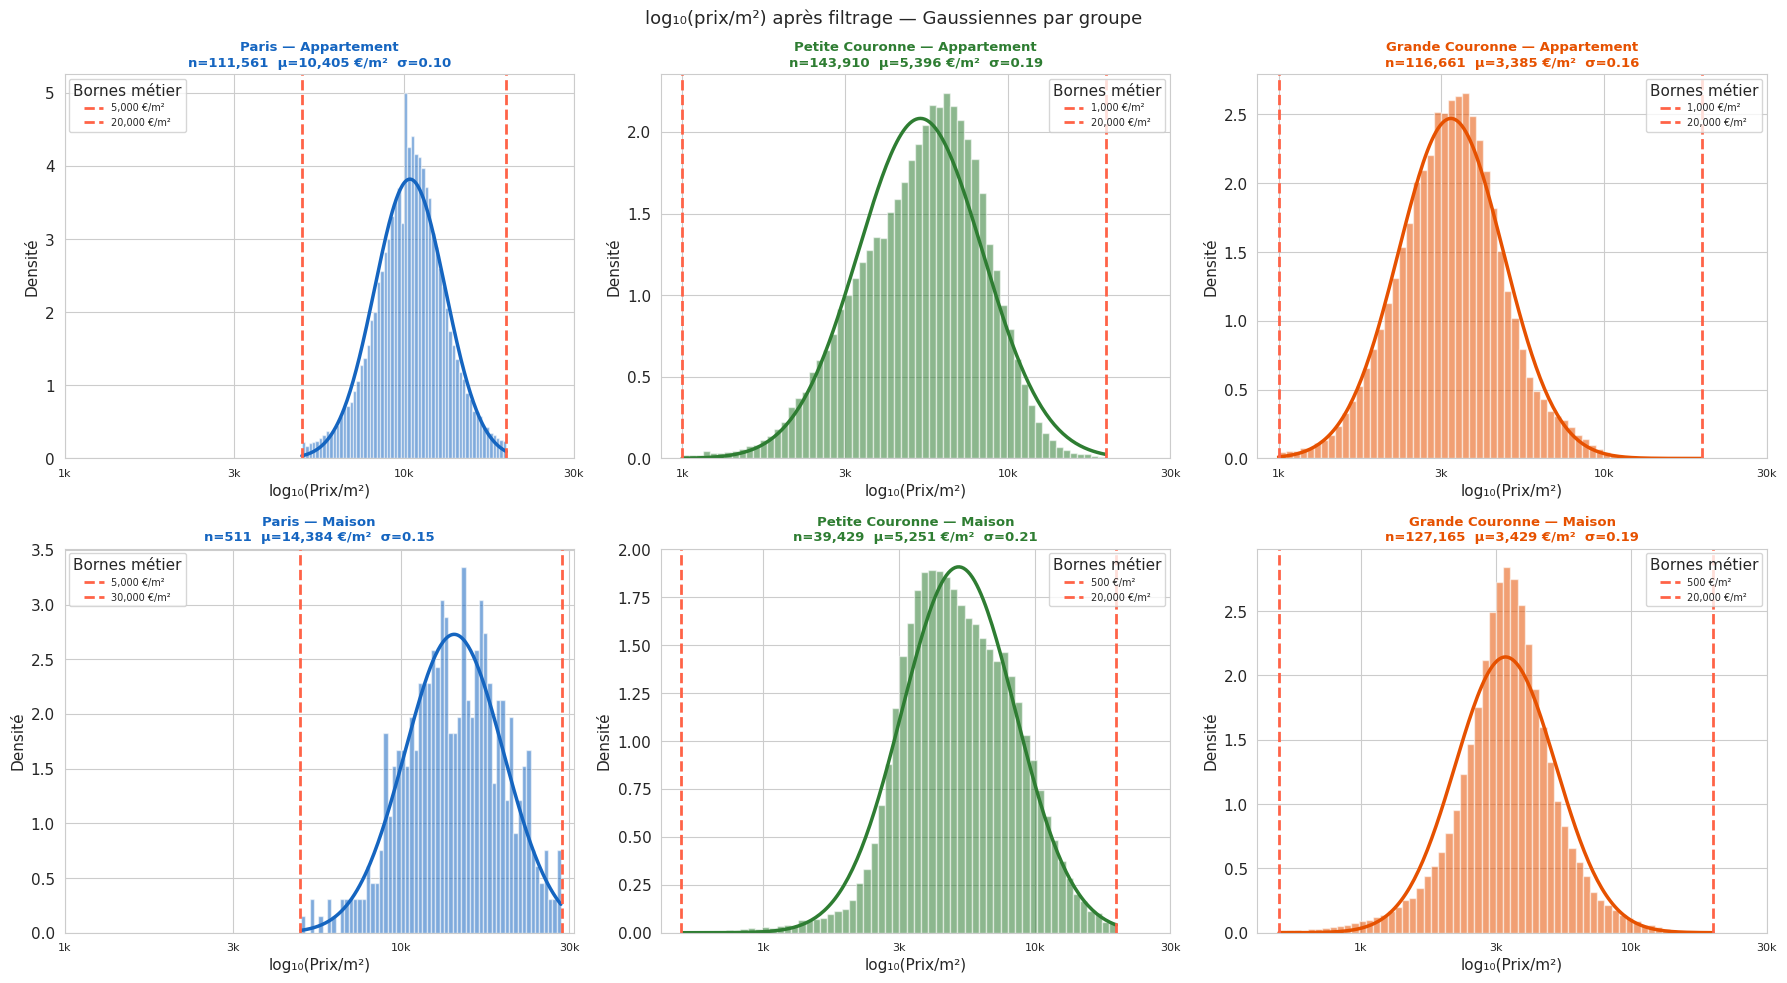

In [ ]:
# ─── Gaussiennes avec barres de filtrage ─────────────────────────────────────
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('log₁₀(prix/m²) après filtrage — Gaussiennes par groupe', fontsize=13)

for row_i, ttype in enumerate(['Appartement', 'Maison']):
    for col_i, zone in enumerate(['Paris', 'Petite Couronne', 'Grande Couronne']):
        ax  = axes[row_i, col_i]
        key = (zone, ttype)
        sub = df_clean[(df_clean['zone']==zone) & (df_clean['type_local']==ttype)]
        if len(sub) < 30:
            ax.set_visible(False)
            continue
        lp    = sub['log_prix_m2']
        color = ZONE_COLORS[zone]

        ax.hist(lp, bins=60, density=True, alpha=0.55, color=color)

        mu, sig = stats.norm.fit(lp)
        x = np.linspace(lp.min(), lp.max(), 200)
        ax.plot(x, stats.norm.pdf(x, mu, sig), color=color, lw=2.5)

        if key in BOUNDS:
            lo, hi = BOUNDS[key]
            ax.axvline(np.log10(lo), color='tomato', ls='--', lw=2,
                       label=f'{lo:,} €/m²')
            ax.axvline(np.log10(hi), color='tomato', ls='--', lw=2,
                       label=f'{hi:,} €/m²')

        ax.set_title(
            f'{zone} — {ttype}\n'
            f'n={len(sub):,}  μ={10**mu:,.0f} €/m²  σ={sig:.2f}',
            fontsize=9.5, color=color, fontweight='bold'
        )
        ax.set_xlabel('log₁₀(Prix/m²)')
        ax.set_ylabel('Densité')
        ax.set_xticks([3.0, 3.5, 4.0, 4.5])
        ax.set_xticklabels(['1k', '3k', '10k', '30k'], fontsize=8)
        ax.legend(fontsize=7, title='Bornes métier')

plt.tight_layout()
plt.show()


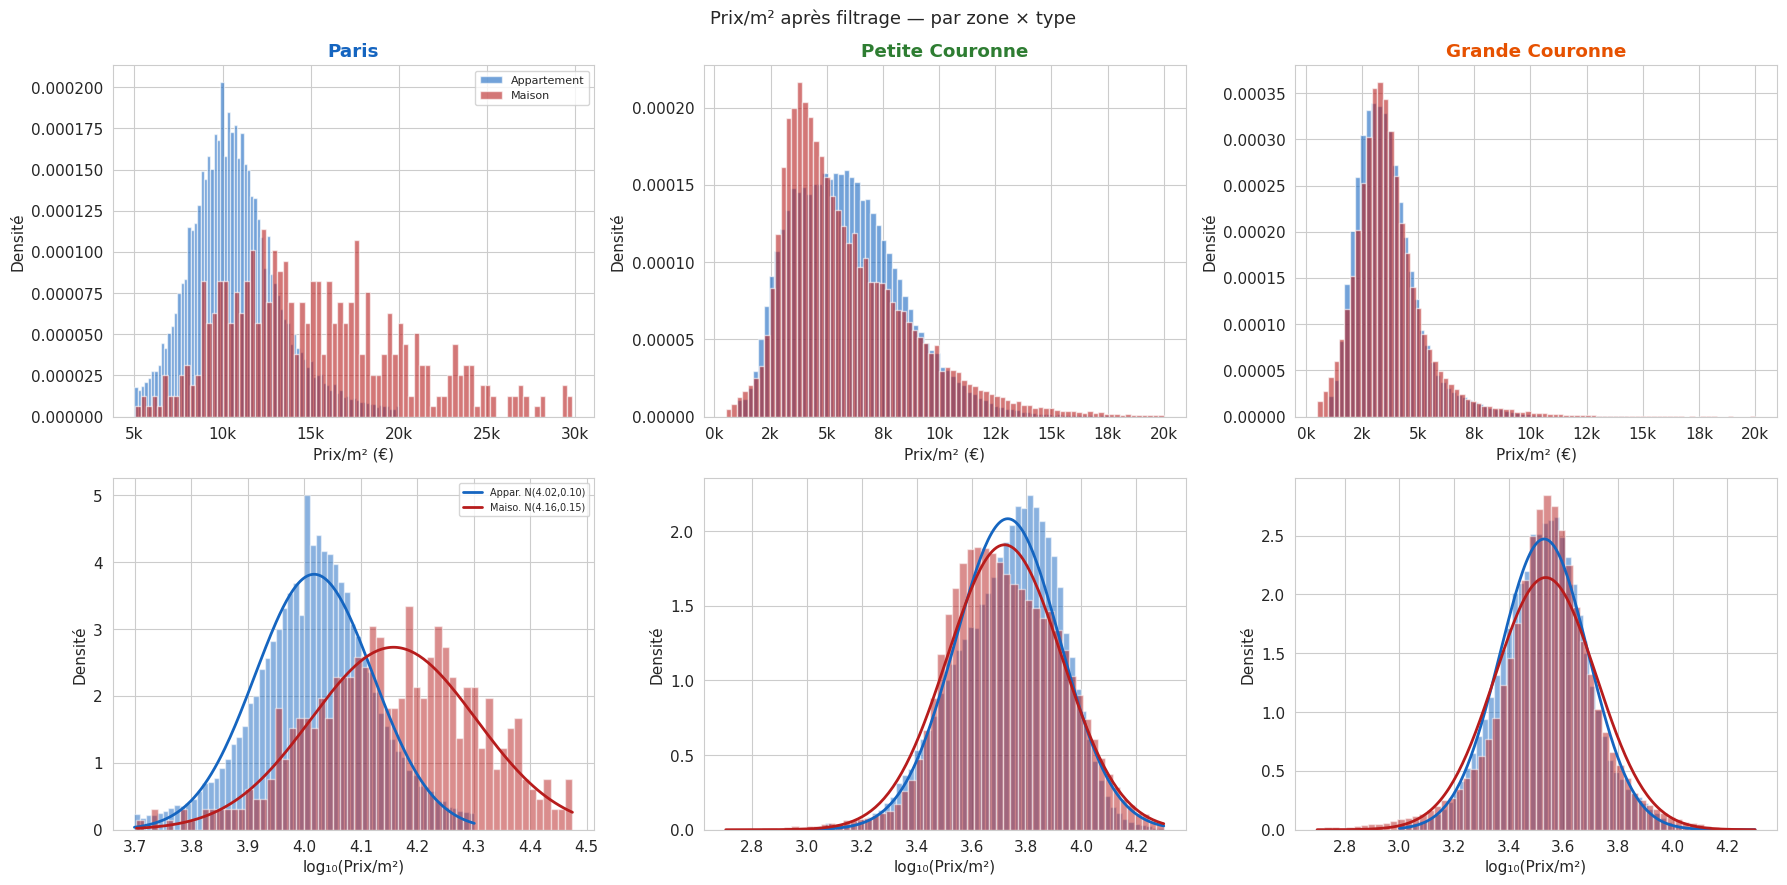

In [ ]:
# ─── Distributions APRÈS filtrage ────────────────────────────────────────────
TYPE_COLORS = {'Appartement': '#1565C0', 'Maison': '#B71C1C'}
ZONE_ORDER  = ['Paris', 'Petite Couronne', 'Grande Couronne']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Prix/m² après filtrage — par zone × type', fontsize=13)

for col_i, zone in enumerate(ZONE_ORDER):
    sub   = df_clean[df_clean['zone'] == zone]
    color = ZONE_COLORS[zone]

    # Ligne 1 : échelle brute
    ax = axes[0, col_i]
    for ttype, grp in sub.groupby('type_local'):
        ax.hist(grp['prix_m2'], bins=80, alpha=0.6, density=True,
                color=TYPE_COLORS.get(ttype,'grey'), label=ttype)
    ax.set_title(zone, color=color, fontweight='bold')
    ax.set_xlabel('Prix/m² (€)')
    ax.set_ylabel('Densité')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}k'))
    if col_i == 0:
        ax.legend(fontsize=8)

    # Ligne 2 : log₁₀ + fit gaussien
    ax = axes[1, col_i]
    for ttype, grp in sub.groupby('type_local'):
        lp = grp['log_prix_m2']
        c  = TYPE_COLORS.get(ttype, 'grey')
        ax.hist(lp, bins=60, alpha=0.5, density=True, color=c)
        mu, sig = stats.norm.fit(lp)
        x = np.linspace(lp.min(), lp.max(), 200)
        ax.plot(x, stats.norm.pdf(x, mu, sig), color=c, lw=2,
                label=f'{ttype[:5]}. N({mu:.2f},{sig:.2f})')
    ax.set_xlabel('log₁₀(Prix/m²)')
    ax.set_ylabel('Densité')
    if col_i == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


---
## 9. Ingénierie des features <a id='9'></a>

On crée des variables dérivées utiles pour l'analyse et la modélisation future.

In [ ]:
# ─── Features temporelles ─────────────────────────────────────────────────────
#-------------------------------------------------------------------------------------------------------
############################################### TO DO ##################################################
# Création des features temporelles (aidez-vous de .dt)
df_clean['annee']      = ...
df_clean['mois']       = ...
df_clean['trimestre']  = ...
df_clean['annee_mois'] = ...
#-------------------------------------------------------------------------------------------------------

# Saisonnalité : label lisible
saison_map = {12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
              3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
              6: 'Été', 7: 'Été', 8: 'Été',
              9: 'Automne', 10: 'Automne', 11: 'Automne'}
df_clean['saison'] = df_clean['mois'].map(saison_map)

print('Features temporelles créées :', ['annee', 'mois', 'trimestre', 'saison'])
print(f'\nPériode couverte : {df_clean["date_mutation"].min().date()} → {df_clean["date_mutation"].max().date()}')
print(f'Années présentes : {sorted(df_clean["annee"].unique())}')

Features temporelles créées : ['annee', 'mois', 'trimestre', 'saison']

Période couverte : 2021-01-01 → 2024-12-31
Années présentes : [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


In [ ]:
# ─── Features géographiques ───────────────────────────────────────────────────

# Labels des départements
DEPT_LABELS = {
    '75': 'Paris',
    '77': 'Seine-et-Marne',
    '78': 'Yvelines',
    '91': 'Essonne',
    '92': 'Hauts-de-Seine',
    '93': 'Seine-Saint-Denis',
    '94': 'Val-de-Marne',
    '95': "Val-d'Oise",
}
df_clean['departement'] = df_clean['code_departement'].map(DEPT_LABELS)

# Zone géographique (zonage classique IDF)
ZONE_MAP = {
    '75': 'Paris',
    '92': 'Petite Couronne', '93': 'Petite Couronne', '94': 'Petite Couronne',
    '77': 'Grande Couronne', '78': 'Grande Couronne',
    '91': 'Grande Couronne', '95': 'Grande Couronne',
}
df_clean['zone'] = df_clean['code_departement'].map(ZONE_MAP)

# Arrondissements parisiens
# Le code_commune pour Paris : 75056 (commune unique Paris)
# Le code_postal donne l'arrondissement : 75001 → 1er, ..., 75020 → 20e
df_clean['arrondissement'] = None
paris_mask = df_clean['code_departement'] == '75'
paris_cp   = df_clean.loc[paris_mask, 'code_postal'].str.extract(r'75(\d{3})')[0]
paris_arr  = paris_cp.str.lstrip('0').apply(
    lambda x: f'Paris {x}e' if (not pd.isna(x) and 1 <= int(x) <= 20) else None
)
# Cas spécial : 75001 → "Paris 1er"
paris_arr = paris_arr.str.replace('Paris 1e$', 'Paris 1er', regex=True)
df_clean.loc[paris_mask, 'arrondissement'] = paris_arr.values

# Résumé
print('Features géographiques créées :', ['departement', 'zone', 'arrondissement'])
print('\nRépartition par zone :')
zone_stats = df_clean.groupby('zone').agg(
    n_transactions=('prix_m2', 'count'),
    prix_m2_median=('prix_m2', 'median')
).round(0)
print(zone_stats.to_string())

Features géographiques créées : ['departement', 'zone', 'arrondissement']

Répartition par zone :
                 n_transactions  prix_m2_median
zone                                           
Grande Couronne          243826          3444.0
Paris                    112072         10476.0
Petite Couronne          183339          5564.0


In [ ]:
# ─── Features sur le bien ─────────────────────────────────────────────────────

# Surface Carrez totale
carrez_cols = [c for c in df_clean.columns if 'surface_carrez' in c]

#-------------------------------------------------------------------------------------------------------
############################################# TO DO ####################################################
# Caculer la surface carrez totale à l'aide de carrez_cols
df_clean['surface_carrez_totale'] = ....
#-------------------------------------------------------------------------------------------------------

#-------------------------------------------------------------------------------------------------------
############################################# TO DO ####################################################
# surface_terrain : pertinente pour les maisons, non-informative pour les apparts
# On crée une version nettoyée : NaN pour les appartements
df_clean['surface_terrain_maison'] = ...
#-------------------------------------------------------------------------------------------------------

pct_terrain_maison = df_clean.loc[df_clean['type_local'] == 'Maison', 'surface_terrain'].gt(0).mean() * 100
print(f'Maisons avec surface_terrain > 0 : {pct_terrain_maison:.1f}%')
print(f'surface_terrain médiane (maisons) : '
      f'{df_clean.loc[df_clean["type_local"]=="Maison","surface_terrain"].median():.0f} m²')

# Typologie (T1, T2, ...)
def categorise_taille(n):
    if pd.isna(n): return 'Inconnu'
    n = int(n)
    if n <= 0: return 'Studio'
    if n <= 5: return f'T{n}'
    return 'T6+'

df_clean['typologie'] = df_clean['nombre_pieces_principales'].apply(categorise_taille)

# Cible log
df_clean['log_prix_m2'] = np.log10(df_clean['prix_m2'])

print('\nFeatures créées :', ['surface_carrez_totale', 'surface_terrain_maison', 'typologie', 'log_prix_m2'])


Maisons avec surface_terrain > 0 : 90.1%
surface_terrain médiane (maisons) : 400 m²

Features créées : ['surface_carrez_totale', 'surface_terrain_maison', 'typologie', 'log_prix_m2']


---
## 10. Export du dataset propre <a id='11'></a>

On exporte le dataset nettoyé pour le réutiliser dans les TDs suivants.

In [ ]:
# ─── Sélection des colonnes finales ───────────────────────────────────────────
EXPORT_COLS = [
    # Identifiant
    'transaction_id',
    # Temporel
    'date_mutation', 'annee', 'mois', 'trimestre', 'saison',
    # Géographique
    'adresse_numero', 'adresse_nom_voie', 'code_postal', 'nom_commune',
    'code_departement', 'departement', 'code_commune', 'zone', 'arrondissement',
    # Type de bien
    'code_type_local', 'type_local', 'nombre_lots',
    # Caractéristiques
    'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain',
    'surface_carrez_totale', 'typologie',
    # Prix
    'valeur_fonciere', 'prix_m2', 'log_prix_m2',
    # Dépendances
    'nb_dependances', 'surface_dependances',
    # Coordonnées GPS
    'latitude', 'longitude',
    # Nature
    'nature_mutation',
]
export_cols_avail = [c for c in EXPORT_COLS if c in df_clean.columns]
df_export = df_clean[export_cols_avail].copy()

print(f'Colonnes exportées : {len(export_cols_avail)}')
print(f'Transactions       : {len(df_export):,}')
print()
print('Aperçu :')
display(df_export.head(3))

Colonnes exportées : 31
Transactions       : 539,237

Aperçu :


,transaction_id,date_mutation,annee,mois,trimestre,saison,adresse_numero,adresse_nom_voie,code_postal,nom_commune,...,surface_carrez_totale,typologie,valeur_fonciere,prix_m2,log_prix_m2,nb_dependances,surface_dependances,latitude,longitude,nature_mutation
0,2021-1289567,2021-01-05,2021,1,1,Hiver,228,RUE DE L EGLISE,77115,Sivry-Courtry,...,NaN,T3,352000.0,2933.333333,3.467361,0,0.0,48.527196,2.755044,Vente
1,2021-1289569,2021-01-05,2021,1,1,Hiver,2,RUE DES BASSES LOGES,77210,Avon,...,59.16,T4,81000.0,1421.052632,3.152610,0,0.0,48.416896,2.733019,Vente
2,2021-1289570,2021-01-08,2021,1,1,Hiver,1,RUE DU MOULIN A VENT,77127,Lieusaint,...,66.22,T3,165000.0,2500.000000,3.397940,1,0.0,48.628821,2.553326,Vente


In [ ]:
# ─── Sauvegarde ───────────────────────────────────────────────────────────────
# OUTPUT_PATH = '/content/drive/MyDrive/DATA_ENPC_PROJECT/dvf_idf_clean.csv'

# df_export.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

# from pathlib import Path
# size_mb = Path(OUTPUT_PATH).stat().st_size / 1e6
# print(f'✓ Dataset sauvegardé : {OUTPUT_PATH}')
# print(f'  Taille : {size_mb:.1f} MB')
# print(f'  Lignes : {len(df_export):,}')
# print(f'  Colonnes : {len(df_export.columns)}')
# print()
# print('Ce fichier sera utilisé comme point de départ du TD 2.')

---
## Conclusion

### Ce que vous avez accompli dans ce TD

| Étape | Défi | Solution |
|---|---|---|
| **Chargement** | Fichier brut avec formats français | Lecture en `str`, conversion explicite |
| **Structure DVF** | 1 ligne ≠ 1 transaction | Agrégation par `transaction_id` |
| **Filtrage** | Biens non résidentiels, ventes atypiques | Filtres sur `nature_mutation` et `type_local` |
| **Outliers** | Erreurs de saisie, cas exceptionnels | Combinaison connaissance métier + IQR |
| **Variable cible** | Prix brut non comparable entre biens | `prix_m2` et `log_prix_m2` |
| **Features** | Variables brutes peu exploitables | Temporal, géographique, typologique |

### Points clés à retenir pour la modélisation (TDs suivants)

1. **La cible est log-normale** → utiliser `log(prix_m2)` pour la régression linéaire
2. **La géographie est le facteur dominant** → `departement` et `zone` sont les features les plus discriminantes
3. **La saisonnalité existe** → `mois` ou `trimestre` apporteront de l'information
4. **Surface et pièces sont corrélées** → attention à la multicolinéarité
5. **Données manquantes restantes** → à traiter dans la pipeline de modélisation

---
*Données : DVF — DGFiP via data.gouv.fr | Projet ENPC Data Science*